# 13. SDE и схема Эйлера — Маруямы

**Статус:** завершено

Схема Эйлера — Маруямы — базовый численный метод для SDE. Мы разберём общий вид SDE, сильную и слабую ошибку, влияние шага времени и сравним приближение с точным решением GBM.

## Общий вид

Одномерное SDE записывают как

$$dX_t=a(t,X_t)dt+b(t,X_t)dW_t.$$

Схема Эйлера — Маруямы на сетке $t_k$:

$$X_{k+1}=X_k+a(t_k,X_k)\Delta t+b(t_k,X_k)\Delta W_k,$$

где $\Delta W_k\sim N(0,\Delta t)$.

Сильная ошибка сравнивает траектории при одном и том же броуновском шуме, слабая ошибка сравнивает ожидания функций от решения. Для практики это разные вопросы: «похожа ли траектория» и «правильно ли считаются средние/payoff».

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.sde_euler_maruyama import (
    calculate_exact_gbm_paths_from_brownian_increments,
    estimate_terminal_strong_errors_for_gbm,
    plot_error_convergence,
    plot_sde_paths,
    simulate_sde_paths_with_euler_maruyama,
)

## 1. GBM через Euler-Maruyama

,Показатель,Значение
0,E[S(1)] EM,108.3873
1,E[S(1)] exact,108.3908
2,mean absolute terminal error,0.3834
3,weak mean error,0.0035


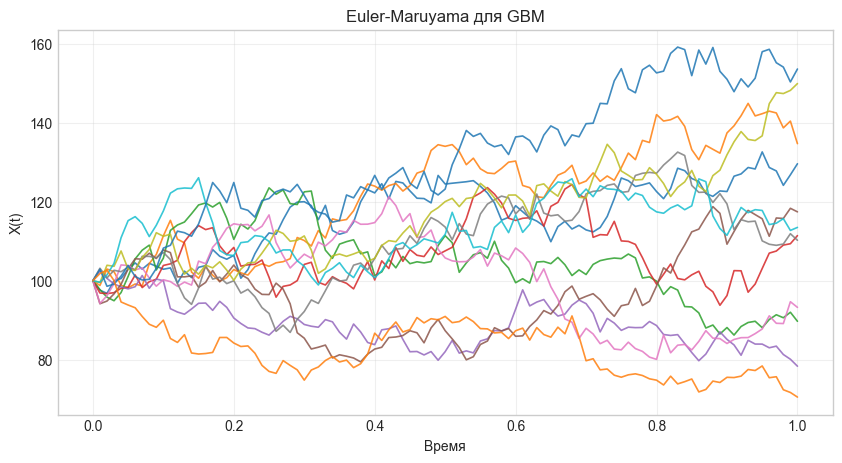

In [2]:
time_grid, em_gbm_paths, brownian_increments = simulate_sde_paths_with_euler_maruyama(
    number_of_paths=5000,
    number_of_time_steps=100,
    final_time=1.0,
    initial_value=100.0,
    drift_function=lambda t, x: 0.08 * x,
    diffusion_function=lambda t, x: 0.25 * x,
    random_seed=123,
)
exact_gbm_paths = calculate_exact_gbm_paths_from_brownian_increments(brownian_increments, 100.0, 0.08, 0.25, 1.0)
plot_sde_paths(time_grid, em_gbm_paths[:12], "Euler-Maruyama для GBM");

pd.DataFrame({
    "Показатель": ["E[S(1)] EM", "E[S(1)] exact", "mean absolute terminal error", "weak mean error"],
    "Значение": [em_gbm_paths[:,-1].mean(), exact_gbm_paths[:,-1].mean(), np.mean(np.abs(em_gbm_paths[:,-1]-exact_gbm_paths[:,-1])), abs(em_gbm_paths[:,-1].mean()-exact_gbm_paths[:,-1].mean())]
})

Euler-Maruyama воспроизводит общую форму GBM, но это дискретное приближение. Даже при одном и том же броуновском шуме терминальная цена отличается от точного решения: сильная ошибка измеряет именно это расхождение траекторий.

Слабая ошибка среднего обычно меньше, потому что положительные и отрицательные ошибки частично компенсируются. Поэтому метод может неплохо оценивать среднее, но хуже восстанавливать конкретную траекторию.

## 2. Сходимость ошибки при уменьшении шага

,steps,strong error,weak mean error
0,25,0.7738,0.0122
1,50,0.5308,0.0002
2,100,0.3782,0.0153
3,200,0.2752,0.0015
4,400,0.1882,0.0016


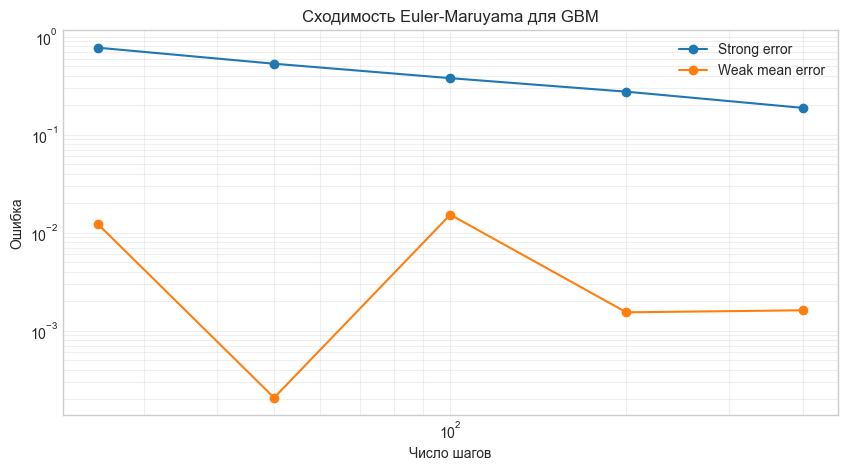

In [3]:
step_counts, strong_errors, weak_errors = estimate_terminal_strong_errors_for_gbm(
    step_counts=[25, 50, 100, 200, 400],
    number_of_paths=4000,
    final_time=1.0,
    initial_value=100.0,
    drift=0.08,
    volatility=0.25,
    random_seed=123,
)
plot_error_convergence(step_counts, strong_errors, weak_errors, "Сходимость Euler-Maruyama для GBM");
pd.DataFrame({"steps": step_counts, "strong error": strong_errors, "weak mean error": weak_errors})

Сильная ошибка убывает при увеличении числа шагов: примерно `0.7738`, `0.5308`, `0.3782`, `0.2752`, `0.1882`. Это ожидаемо: более мелкая сетка лучше приближает стохастический интеграл.

Слабая ошибка среднего гораздо более шумная и малая: она зависит от Monte Carlo погрешности и компенсации ошибок. В задачах ценообразования часто важнее слабая точность payoff, а в задачах фильтрации или pathwise risk — сильная точность.

## 3. Нелинейная SDE и роль шага

,Сетка,E[X(2)],Var[X(2)]
0,50 шагов,2.4238,0.4134
1,500 шагов,2.3963,0.4178


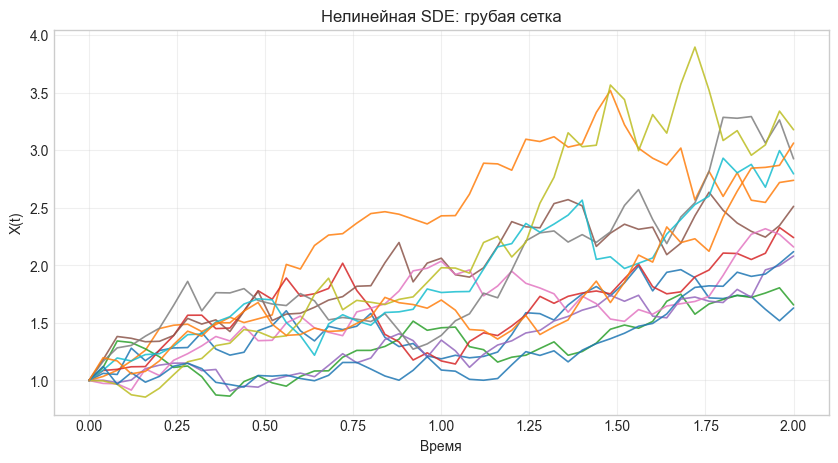

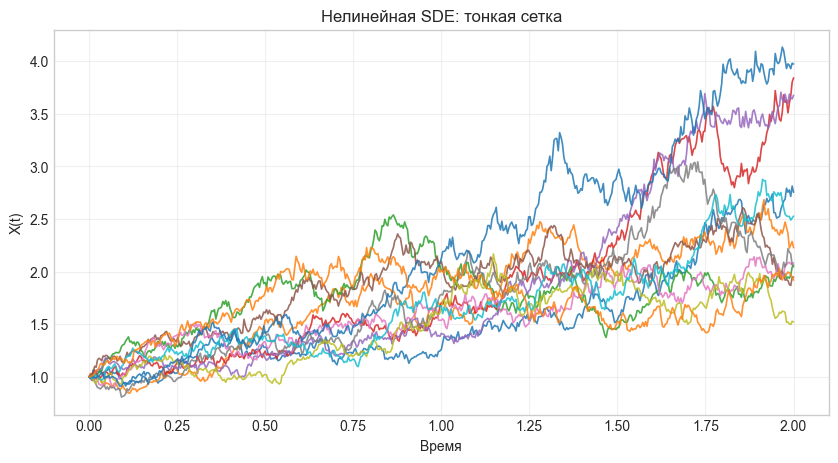

In [4]:
time_grid_coarse, coarse_paths, _ = simulate_sde_paths_with_euler_maruyama(2000, 50, 2.0, 1.0, lambda t,x: 1.2*x*(1-x/3), lambda t,x: 0.35*x, random_seed=77)
time_grid_fine, fine_paths, _ = simulate_sde_paths_with_euler_maruyama(2000, 500, 2.0, 1.0, lambda t,x: 1.2*x*(1-x/3), lambda t,x: 0.35*x, random_seed=77)
plot_sde_paths(time_grid_coarse, coarse_paths[:12], "Нелинейная SDE: грубая сетка");
plot_sde_paths(time_grid_fine, fine_paths[:12], "Нелинейная SDE: тонкая сетка");
pd.DataFrame({"Сетка": ["50 шагов", "500 шагов"], "E[X(2)]": [coarse_paths[:,-1].mean(), fine_paths[:,-1].mean()], "Var[X(2)]": [coarse_paths[:,-1].var(), fine_paths[:,-1].var()]})

Для нелинейных SDE шаг времени становится особенно важным: drift и diffusion меняются вместе с состоянием, поэтому грубая сетка может искажать динамику. Визуально тонкая сетка даёт более устойчивую картину, а численные моменты немного меняются.

## Выводы

1. Euler-Maruyama — прямой дискретный аналог SDE.
2. Сильная ошибка сравнивает траектории, слабая — ожидания.
3. Уменьшение шага снижает дискретизационную ошибку, но повышает стоимость симуляции.
4. Для моделей с точным решением, таких как GBM, полезно сравнивать EM с exact benchmark.
5. Для нелинейных SDE выбор шага может существенно влиять на выводы.